# Capstone — Primer análisis exploratorio

**¿Es igual de difícil clasificar a un campeonato nadando en piscina de 25 m o de 50 m?**

Felipe Leiva Díaz y Javier Fuentes · Diplomado en Ciencia de Datos Aplicada, UTFSM
Módulo 1, evaluación 2 · Entrega: lunes 15 de septiembre de 2026

---

## La pregunta

El mismo nadador va más rápido en piscina de 25 m que en una de 50 m, porque da el
doble de vueltas y cada vuelta regala tiempo: empuja la pared y viaja bajo el agua,
que es más rápido que nadar en superficie. La razón entre ambas marcas es el
**factor de conversión**:

$$\text{factor} = \frac{t_{50\text{m}}}{t_{25\text{m}}}$$

**Pregunta:** ¿es constante ese factor, o depende del estilo, la distancia y el sexo?

**Hipótesis verificable:** si la ventaja de la piscina corta viniera *solo* de dar
más vueltas y cada vuelta valiera lo mismo, la diferencia entre piscinas sería
proporcional a las vueltas extra (`distancia / 50`) y el factor sería el mismo en
todas las pruebas. Si el factor cambia sistemáticamente por estilo, la hipótesis
del "modelo simple" queda descartada.

**Por qué importa:** World Aquatics acepta marcas de ambas piscinas para clasificar
a un campeonato, con **dos tablas de mínimas separadas**. La razón entre esas dos
exigencias es la equivalencia que la federación aplica de hecho. Si no coincide con
la real, clasificar es más difícil en una piscina que en la otra, y cuánto depende
de la prueba.

## Los datos

Rankings de la temporada 2024 de la API pública de World Aquatics
(`https://api.worldaquatics.com/fina/rankings/swimming`), 12 pruebas × 2 sexos ×
2 piscinas = 48 consultas en modo `BEST_TIMES` (la mejor marca del año de cada
nadador). El script `descargar.py` de este mismo directorio las reproduce.

> **Nota sobre el archivo de datos.** `datos/nados.csv` (62 MB) no se adjunta: los
> términos legales de World Aquatics prohíben la redistribución de sus contenidos.
> Para regenerarlo: `uv run python descargar.py` desde `~/diplomado-cdd`. El script
> cachea cada respuesta, así que una segunda corrida no vuelve a pedir nada.

## Declaración de uso de IA

Se usó Claude (Anthropic) para explorar la documentación de la API, discutir el
diseño del análisis y revisar código. Los datos, las decisiones metodológicas y la
interpretación son de los autores, que pueden explicar cada parte de lo entregado.

---
# 1. Los datos y su calidad

**Objetivo de la sección:** cargar los rankings tal como vienen de la API, describir
su tamaño y sus tipos, y dejar por escrito cada problema de calidad encontrado y qué
se decidió hacer con él.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

# Paleta Okabe-Ito: legible también para daltonismo
COLORES = {"FREESTYLE": "#0072B2", "BACKSTROKE": "#D55E00",
           "BREASTSTROKE": "#009E73", "BUTTERFLY": "#CC79A7",
           "MEDLEY": "#E69F00"}
NOMBRES = {"FREESTYLE": "Libre", "BACKSTROKE": "Espalda",
           "BREASTSTROKE": "Pecho", "BUTTERFLY": "Mariposa", "MEDLEY": "Combinado"}
GRIS = "#6E878D"
ORDEN = ["FREESTYLE", "BUTTERFLY", "MEDLEY", "BREASTSTROKE", "BACKSTROKE"]

crudo = pd.read_csv("datos/nados.csv")
print(f"Filas: {len(crudo):,}   Columnas: {crudo.shape[1]}")
crudo.head(3)

Filas: 193,142   Columnas: 25


,anio,sexo,piscina,distancia,estilo,prueba,rank,tiempo,tiempo_s,puntos_fina,nombre,person_id,fecha_nacimiento,edad,pais,pais_codigo,club,fecha,competencia,ciudad,medalla,record,result_id,event_id,discipline_id
0,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,1,21.13,21.13,969.0,MCEVOY Cameron,9f6cbeb2-7f23-4d65-aae9-4d934caf9785,1994-05-13T00:00:00,29.0,Australia,AUS,No,2024-02-16T00:00:00,World Aquatics Championships - Doha 2024,Doha,NaN,NaN,R1000604,7dc47aca-99a9-4719-aedc-41118d97be8a,54f8e2e1-0506-47f3-bc16-14648cee1369
1,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,2,21.25,21.25,952.0,PROUD Benjamin,e267cb35-3d81-4548-aab2-dd1d00ca78d6,1994-09-21T00:00:00,29.0,Great Britain,GBR,University of Bath SC,2024-04-06T00:00:00,GBR Championships 2024,London,1.0,NaN,R1000849,2ab874b4-94e0-46d9-9342-8ce02f42b5d7,54f8e2e1-0506-47f3-bc16-14648cee1369
2,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,3,21.38,21.38,935.0,BUKHOV Vladyslav,56aaa233-94a5-45cf-bfd8-e72b28c7431d,2002-07-05T00:00:00,21.0,Ukraine,UKR,No,2024-02-16T00:00:00,World Aquatics Championships - Doha 2024,Doha,NaN,[0],R1190363,7dc47aca-99a9-4719-aedc-41118d97be8a,54f8e2e1-0506-47f3-bc16-14648cee1369


## 1.1 Tipos, faltantes y cardinalidad

*Objetivo: saber con qué tipo de variable estamos tratando en cada columna y dónde
hay ausencias, antes de calcular nada.*

In [2]:
resumen = pd.DataFrame({
    "tipo": crudo.dtypes.astype(str),
    "nulos": crudo.isna().sum(),
    "% nulos": (crudo.isna().mean() * 100).round(2),
    "distintos": crudo.nunique(),
})
resumen

,tipo,nulos,% nulos,distintos
anio,int64,0,0.00,1
sexo,object,0,0.00,2
piscina,object,0,0.00,2
distancia,int64,0,0.00,4
estilo,object,0,0.00,5
prueba,object,0,0.00,24
rank,int64,0,0.00,5000
tiempo,object,0,0.00,25755
tiempo_s,float64,0,0.00,25755
puntos_fina,float64,0,0.00,968


Tres grupos de columnas, y conviene no confundirlos:

- **Las que no tienen ni un nulo** (`tiempo_s`, `person_id`, `distancia`, `estilo`,
  `puntos_fina`, `pais`): son el núcleo del análisis y llegan completas.
- **`edad` y `fecha_nacimiento`, con 6,33% de nulos**: ausencia real. Hay nadadores
  sin fecha de nacimiento cargada.
- **`medalla` (91,5%) y `record` (99,3%)**: *no son datos faltantes*. Un nulo ahí
  significa "ese nado no ganó medalla" y "ese nado no fue récord". Tratarlos como
  faltantes e imputarlos sería un error de lectura del dominio.

In [3]:
print("Nadadores distintos :", f"{crudo['person_id'].nunique():,}")
print("Países              :", crudo["pais"].nunique())
print("Competencias        :", crudo["competencia"].nunique())
print("\nNados por sexo y piscina:")
print(crudo.groupby(["sexo", "piscina"]).size().unstack(fill_value=0).to_string())

Nadadores distintos : 56,035
Países              : 201
Competencias        : 306

Nados por sexo y piscina:
piscina    LCM    SCM
sexo                 
F        56056  37738
M        57663  41685


## 1.2 Faltantes disfrazados

*Objetivo: buscar ausencias que no se ven como `NaN`, que es el caso que la clase 2
advertía (códigos 999, −1, textos centinela).*

Encontramos dos.

In [4]:
print("Los 6 valores más frecuentes de 'club':")
print(crudo["club"].value_counts().head(6).to_string())
club_no = (crudo["club"] == "No").sum()
print(f"\nEl literal 'No' aparece {club_no:,} veces ({club_no/len(crudo):.1%} de las filas).")
print("No es un club: es el centinela con que la API marca 'sin club'.")

Los 6 valores más frecuentes de 'club':
club
No                 30483
Москва               917
Cetus Espoo          881
Санкт-Петербург      875
ZJ                   762
Минск                549

El literal 'No' aparece 30,483 veces (15.8% de las filas).
No es un club: es el centinela con que la API marca 'sin club'.


In [5]:
print("Edad declarada:")
print(crudo["edad"].describe(percentiles=[.01, .5, .99]).round(1).to_string())
print("\nEdades fuera de un rango humano posible para competencia:")
print(crudo.loc[~crudo["edad"].between(8, 70) & crudo["edad"].notna(),
                ["nombre", "pais_codigo", "edad", "fecha_nacimiento"]].to_string(index=False))

Edad declarada:
count    180918.0
mean         17.2
std           3.5
min           7.0
1%           12.0
50%          17.0
99%          29.0
max         119.0

Edades fuera de un rango humano posible para competencia:
        nombre pais_codigo  edad    fecha_nacimiento
SCHWIETERT Ben         CLB 119.0 1905-06-19T00:00:00
SCHWIETERT Ben         CLB 119.0 1905-06-19T00:00:00
   BUSS Volker         CLB  72.0 1951-12-29T00:00:00
LEDENT Matthew         CLB   7.0 2016-12-21T00:00:00
  MASSARD Loyc         CLB   7.0 2016-12-06T00:00:00
LEDENT Matthew         CLB   7.0 2016-12-21T00:00:00


Seis filas caen fuera del rango: dos con 119 años (nacido en 1905), una con 72 y
tres con 7. Las de 119 son sin duda un error de carga en el origen; las de 7 y 72
son implausibles para un ranking mundial. **Todas comparten el mismo
`pais_codigo` = `CLB`**, que no es un país sino otro centinela de la API — señal de
que estas filas vienen de un registro mal formado.

**Decisión:** `club == "No"` pasa a `NaN` y las edades fuera de \[8, 70\] pasan a
`NaN`. No se borran las filas: el resto de la fila (el tiempo, que es lo que nos
interesa) sigue siendo válido, y `edad` no entra en el cálculo del factor.

In [6]:
limpio = crudo.copy()
limpio["club"] = limpio["club"].replace("No", np.nan)
limpio.loc[~limpio["edad"].between(8, 70), "edad"] = np.nan
print(f"'club' nulo tras la corrección: {limpio['club'].isna().mean():.1%}")
print(f"'edad' nula tras la corrección: {limpio['edad'].isna().mean():.2%}")

'club' nulo tras la corrección: 15.8%
'edad' nula tras la corrección: 6.33%


## 1.3 Duplicados

*Objetivo: comprobar que `BEST_TIMES` cumple lo que promete —una fila por nadador en
cada prueba y piscina—, porque todo el cruce posterior depende de eso.*

Este control es el que faltaba en nuestra primera descarga: pedir "los 5.000 mejores
tiempos" traía al mismo nadador varias veces y el factor salía mal.

In [7]:
llave = ["anio", "sexo", "distancia", "estilo", "piscina", "person_id"]
repetidos = limpio.duplicated(subset=llave).sum()
print(f"Filas duplicadas por {tuple(llave)}: {repetidos}")
assert repetidos == 0, "Hay nadadores repetidos: revisar la descarga antes de seguir"
print("OK — cada fila es un nadador distinto en su prueba y piscina.")

Filas duplicadas por ('anio', 'sexo', 'distancia', 'estilo', 'piscina', 'person_id'): 0
OK — cada fila es un nadador distinto en su prueba y piscina.


## 1.4 Valores imposibles del dominio

*Objetivo: descartar tiempos que no pueden corresponder a un nado real. Para poder
comparar pruebas de distinta distancia usamos los **segundos por metro**.*

In [8]:
limpio["s_por_metro"] = limpio["tiempo_s"] / limpio["distancia"]
print(limpio["s_por_metro"].describe(percentiles=[.001, .01, .5, .99, .999]).round(3).to_string())

count    193142.000
mean          0.667
std           0.110
min           0.398
0.1%          0.438
1%            0.466
50%           0.659
99%           0.984
99.9%         1.180
max           3.076


In [9]:
# Referencia: el récord mundial de 50 libre son ~0,41 s/m. Cortamos en 0,38 por abajo
# (nadie puede ser más rápido que eso) y en 2,0 por arriba, que es muy generoso:
# saca sólo lo que con seguridad es un error de registro.
LIM_BAJO, LIM_ALTO = 0.38, 2.0
fuera = limpio[~limpio["s_por_metro"].between(LIM_BAJO, LIM_ALTO)]
print(f"Nados fuera de [{LIM_BAJO}, {LIM_ALTO}] s/m: {len(fuera)} de {len(limpio):,}")
if len(fuera):
    print(fuera[["prueba", "piscina", "nombre", "pais_codigo", "tiempo", "s_por_metro"]]
          .head(10).to_string(index=False))

antes = len(limpio)
limpio = limpio[limpio["s_por_metro"].between(LIM_BAJO, LIM_ALTO)].copy()
print(f"\nFilas antes: {antes:,}  ->  después: {len(limpio):,}  (se descartan {antes-len(limpio)})")

Nados fuera de [0.38, 2.0] s/m: 3 de 193,142
                   prueba piscina         nombre pais_codigo  tiempo  s_por_metro
   Women's 200m Freestyle     SCM JOHANSSON Lova         SWE 8:23.48       2.5174
  Women's 100m Backstroke     SCM JOHANSSON Lova         SWE 4:25.04       2.6504
Women's 100m Breaststroke     SCM JOHANSSON Lova         SWE 5:07.61       3.0761



Filas antes: 193,142  ->  después: 193,139  (se descartan 3)


## 1.5 El cruce LCM ↔ SCM, verificado con conteos

*Objetivo: construir la tabla que responde la pregunta. Cruzamos cada nadador
**consigo mismo**: su marca en piscina de 50 m (LCM) contra la suya en piscina de
25 m (SCM), misma prueba y mismo año.*

Comparar a alguien con su propia marca elimina de un plumazo el talento, la edad, el
entrenamiento y todo lo demás que separaría a dos personas distintas. Es un diseño
**dentro-nadador**.

In [10]:
llaves = ["anio", "sexo", "distancia", "estilo", "person_id"]
largo = limpio[limpio["piscina"] == "LCM"]
corto = limpio[limpio["piscina"] == "SCM"]
print(f"Filas en piscina de 50 m (LCM): {len(largo):,}")
print(f"Filas en piscina de 25 m (SCM): {len(corto):,}")

pares = largo.merge(
    corto[llaves + ["tiempo_s", "tiempo", "fecha", "competencia"]],
    on=llaves, how="inner", suffixes=("_lcm", "_scm"), validate="one_to_one",
)
print(f"\nPares tras el merge          : {len(pares):,}")
print(f"Sin par en LCM               : {len(largo) - len(pares):,}")
print(f"Sin par en SCM               : {len(corto) - len(pares):,}")
print(f"\nNadadores distintos con par  : {pares['person_id'].nunique():,}"
      f"  (de {limpio['person_id'].nunique():,} en la muestra)")

Filas en piscina de 50 m (LCM): 113,719
Filas en piscina de 25 m (SCM): 79,420



Pares tras el merge          : 30,257
Sin par en LCM               : 83,462
Sin par en SCM               : 49,163

Nadadores distintos con par  : 12,531  (de 56,034 en la muestra)


El merge es `inner` y `one_to_one`: Pandas falla si algún nadador apareciera dos
veces en un lado, así que el conteo de salida no puede estar inflado. Se pierde la
mayoría de las filas y eso es esperable — casi nadie compite el mismo año en las dos
piscinas — pero quedan 30.257 pares, más que suficiente.

In [11]:
pares["diferencia_s"]  = pares["tiempo_s_lcm"] - pares["tiempo_s_scm"]
pares["factor"]        = pares["tiempo_s_lcm"] / pares["tiempo_s_scm"]
pares["vueltas_extra"] = pares["distancia"] / 50
pares["por_vuelta_s"]  = pares["diferencia_s"] / pares["vueltas_extra"]

print("Pares por prueba (mínimo por combinación):")
conteo = pares.groupby(["sexo", "prueba"]).size()
print(f"  mínimo {conteo.min():,} · mediana {int(conteo.median()):,} · máximo {conteo.max():,}")

Pares por prueba (mínimo por combinación):
  mínimo 570 · mediana 1,351 · máximo 1,747


In [12]:
# Control de sanidad: la piscina de 25 m debería ser más rápida casi siempre.
al_reves = (pares["diferencia_s"] < 0).sum()
print(f"Casos donde la piscina de 50 m fue más rápida: {al_reves:,} de {len(pares):,} "
      f"({al_reves/len(pares):.1%})")

Casos donde la piscina de 50 m fue más rápida: 3,466 de 30,257 (11.5%)


Ese 11,5% no son errores: son nadadores que ese año estuvieron en forma en una
temporada y no en la otra (la de piscina corta y la de piscina larga son
calendarios distintos). **Se conservan**: sacarlos recortaría una cola y sólo una,
lo que subiría el factor artificialmente. Se declara como limitación.

## 1.6 Bitácora de limpieza

| # | Problema detectado | Decisión |
|---|---|---|
| 1 | `club` trae el texto `"No"` en 15,8% de las filas (faltante disfrazado) | Se reemplaza por `NaN`; no se usa en el análisis |
| 2 | `edad` con 6 valores imposibles (119 años, menores de 8) | Esos valores pasan a `NaN`; la fila se conserva |
| 3 | `medalla` y `record` casi siempre nulos | **No** se tratan como faltantes: el nulo significa "no aplica" |
| 4 | Posibles nadadores repetidos por prueba y piscina | Verificado con `duplicated`: 0 repetidos, `assert` en el notebook |
| 5 | Tiempos absurdos | Filtro por segundos por metro en \[0,38 · 2,0\]; se documenta cuántos salen |
| 6 | El merge podría duplicar filas | `validate="one_to_one"` y conteos antes/después |
| 7 | 11,5% de pares con la piscina de 50 m más rápida | Se conservan (recortar una sola cola sesgaría el factor) |

---
# 2. Estadística descriptiva

**Objetivo de la sección:** describir centro, dispersión y forma de las variables que
entran en la pregunta, y decidir con esa forma qué resúmenes corresponde usar.

> **Sobre ponderación.** Los rankings de World Aquatics **no traen factores de
> expansión ni pesos de muestreo**: cada fila es un nado registrado, no una unidad
> muestral que represente a otras. No corresponde inventarlos. Lo que sí hay que
> declarar es que la muestra **no es aleatoria**: son los mejores nadadores de cada
> prueba, así que todo lo que sigue describe a la élite competitiva y no a la
> población de nadadores.

In [13]:
variables = {
    "factor": "razón t(50 m) / t(25 m), adimensional",
    "diferencia_s": "t(50 m) − t(25 m), en segundos",
    "por_vuelta_s": "segundos ganados por vuelta extra",
    "tiempo_s_lcm": "marca en piscina de 50 m, en segundos",
    "edad": "edad del nadador, en años",
    "puntos_fina": "puntaje FINA de la marca en 50 m, puntos",
}

filas = []
for col, desc in variables.items():
    s = pares[col].dropna()
    filas.append({
        "variable": col, "n": len(s),
        "media": s.mean(), "mediana": s.median(),
        "desv_est": s.std(), "IQR": s.quantile(.75) - s.quantile(.25),
        "asimetría": stats.skew(s), "curtosis": stats.kurtosis(s),
        "mín": s.min(), "máx": s.max(),
    })
desc = pd.DataFrame(filas).set_index("variable").round(3)
desc

,n,media,mediana,desv_est,IQR,asimetría,curtosis,mín,máx
variable,,,,,,,,,
factor,30257,1.031,1.031,0.028,0.033,-0.203,2.390,0.667,1.224
diferencia_s,30257,3.496,2.510,4.184,4.270,1.360,7.285,-64.760,45.130
por_vuelta_s,30257,0.964,0.947,0.912,1.019,-0.180,5.927,-16.190,7.610
tiempo_s_lcm,30257,111.753,77.780,74.622,84.320,1.129,0.584,21.480,408.920
edad,28310,17.814,17.000,3.370,3.000,1.313,2.985,10.000,45.000
puntos_fina,30257,647.005,642.000,104.920,138.000,0.075,0.067,222.000,1030.000


**Cómo se lee esta tabla, en el contexto del problema.**

- **`factor`**: media y mediana coinciden en **1,031**. Un nadador de élite tarda,
  en promedio, un **3,1% más** en piscina de 50 m que en la de 25 m. La dispersión
  es pequeña (desviación 0,028) pero no despreciable: en una prueba de 4 minutos,
  un punto porcentual son 2,4 segundos, que en natación es una eternidad.
- **`diferencia_s`**: media 3,50 s contra mediana 2,51 s, con **asimetría +1,36 y
  curtosis 7,28**. La distribución tiene una cola derecha larga y colas pesadas,
  porque la diferencia en segundos crece con la duración de la prueba: 400 m
  combinado y 50 m libre están en la misma columna. **Para esta variable la media
  engaña y hay que usar la mediana.**
- **`por_vuelta_s`**: mediana 0,95 s. Cada vuelta extra vale, típicamente, un poco
  menos de un segundo. Es la variable que permite comparar pruebas de distinta
  distancia en pie de igualdad.
- **`tiempo_s_lcm`**: media 111,8 s contra mediana 77,8 s. No es una distribución
  con centro: es la mezcla de cuatro distancias distintas (50, 100, 200 y 400 m).
  Describirla globalmente no tiene sentido; **hay que describirla por prueba.**
- **`edad`**: mediana 17 años, IQR de 3. La muestra es mucho más joven de lo que
  sugiere la palabra "élite": la API carga campeonatos nacionales y juveniles.
- **`puntos_fina`**: mediana 642 puntos, simétrica (asimetría 0,07). Un puntaje
  FINA de 1000 equivale al récord mundial; 642 es un buen nivel nacional.

**Conclusión metodológica de la sección:** por la asimetría y las colas pesadas de
`diferencia_s` y `por_vuelta_s`, de aquí en adelante se resume con **mediana e IQR**,
no con media y desviación, y las correlaciones se calculan también con **Spearman**.

In [14]:
# El mismo cuadro, ahora donde sí tiene sentido: por prueba.
por_prueba = (pares.groupby(["sexo", "estilo", "distancia"])
                   .agg(n=("factor", "size"),
                        factor_mediana=("factor", "median"),
                        factor_IQR=("factor", lambda x: x.quantile(.75) - x.quantile(.25)),
                        dif_mediana_s=("diferencia_s", "median"),
                        por_vuelta_s=("por_vuelta_s", "median"))
                   .round(4))
por_prueba

n  factor_mediana  factor_IQR  dif_mediana_s  por_vuelta_s
sexo estilo       distancia                                                               
F    BACKSTROKE   100        1453          1.0409      0.0313          2.630        1.3150
                  200         988          1.0413      0.0296          5.820        1.4550
     BREASTSTROKE 100        1423          1.0335      0.0320          2.450        1.2250
                  200         998          1.0329      0.0322          5.215        1.3037
     BUTTERFLY    100        1436          1.0145      0.0300          0.935        0.4675
                  200         649          1.0250      0.0284          3.480        0.8700
     FREESTYLE    50         1692          1.0201      0.0285          0.530        0.5300
                  100        1677          1.0198      0.0266          1.140        0.5700
                  200        1470          1.0227      0.0267          2.850        0.7125
                  400        1145          1.0254      0.0256          6.730        0.8413
     MEDLEY       200         968          1.0306      0.0255          4.320        1.0800
                  400         570          1.0334      0.0248          9.845        1.2306
M    BACKSTROKE   100        1366          1.0491      0.0327          2.760        1.3800
                  200         989          1.0521      0.0337          6.500        1.6250
     BREASTSTROKE 100        1563          1.0415      0.0305          2.630        1.3150
                  200        1150          1.0450      0.0331          6.205        1.5512
     BUTTERFLY    100        1542          1.0204      0.0311          1.130        0.5650
                  200         926          1.0339      0.0331          4.190        1.0475
     FREESTYLE    50         1747          1.0293      0.0314          0.670        0.6700
                  100        1745          1.0304      0.0275          1.540        0.7700
                  200        1620          1.0326      0.0302          3.605        0.9012
                  400        1336          1.0319      0.0299          7.700        0.9625
     MEDLEY       200        1073          1.0389      0.0296          4.940        1.2350
                  400         731          1.0400      0.0291         10.840        1.3550

---
# 3. Análisis bivariado

**Objetivo de la sección:** medir de qué depende el factor. Cada análisis declara
antes qué quiere relacionar y por qué.

## 3.1 ¿El factor depende de la distancia de la prueba?

*Objetivo: si el modelo simple —cada vuelta vale lo mismo— fuera cierto, el factor
no debería depender de la distancia. Se usa Pearson y Spearman porque la relación
puede no ser lineal (sólo hay cuatro distancias posibles).*

In [15]:
d = pares[["factor", "distancia"]].dropna()
r, pr = stats.pearsonr(d["factor"], d["distancia"])
rho, pp = stats.spearmanr(d["factor"], d["distancia"])
print(f"factor vs distancia   Pearson r = {r:+.3f} (p = {pr:.1e})")
print(f"                      Spearman rho = {rho:+.3f} (p = {pp:.1e})")
print(f"\nMediana del factor por distancia:")
print(pares.groupby("distancia")["factor"].agg(["size", "median"]).round(4).to_string())

factor vs distancia   Pearson r = +0.084 (p = 2.1e-48)
                      Spearman rho = +0.110 (p = 9.5e-83)

Mediana del factor por distancia:
            size  median
distancia               
50          3439  1.0247
100        12205  1.0305
200        10831  1.0348
400         3782  1.0314


La correlación es **positiva pero muy débil** (rho = +0,11): sobre toda la muestra,
la distancia casi no explica el factor. Y la mediana por distancia ni siquiera es
monótona — 400 m queda por debajo de 200 m. Pero esa cifra global mezcla estilos,
así que hay que mirar dentro de cada uno.

Conviene además separar las dos variables, porque no se comportan igual: el
**factor** es una razón, mientras que los **segundos por vuelta extra** miden la
ventaja en la unidad en que se produce. La celda siguiente cuenta, estilo por
estilo, en cuántos casos cada una crece al aumentar la distancia.

In [16]:
# ¿Crece con la distancia, dentro de cada estilo y sexo?
filas = []
for (sx, es), g in pares.groupby(["sexo", "estilo"]):
    m = g.groupby("distancia")[["factor", "por_vuelta_s"]].median().sort_index()
    if len(m) < 2:
        continue
    filas.append({"sexo": sx, "estilo": NOMBRES[es], "distancias": len(m),
                  "factor_crece": bool(m["factor"].is_monotonic_increasing),
                  "por_vuelta_crece": bool(m["por_vuelta_s"].is_monotonic_increasing)})
mono = pd.DataFrame(filas)
print(mono.to_string(index=False))
print(f"\nEl factor crece con la distancia en {mono['factor_crece'].sum()} de {len(mono)} casos.")
print(f"Los segundos por vuelta extra crecen en {mono['por_vuelta_crece'].sum()} de {len(mono)}.")

sexo    estilo  distancias  factor_crece  por_vuelta_crece
   F   Espalda           2          True              True
   F     Pecho           2         False              True
   F  Mariposa           2          True              True
   F     Libre           4         False              True
   F Combinado           2          True              True
   M   Espalda           2          True              True
   M     Pecho           2          True              True
   M  Mariposa           2          True              True
   M     Libre           4         False              True
   M Combinado           2          True              True

El factor crece con la distancia en 7 de 10 casos.
Los segundos por vuelta extra crecen en 10 de 10.


La distinción importa. **El factor no crece siempre**: en pecho femenino y en libre
(ambos sexos) la razón se estanca o baja en la distancia más larga, porque el
denominador crece más rápido que la ventaja acumulada. **Los segundos ganados por
vuelta extra, en cambio, crecen con la distancia en los diez casos, sin
excepción.**

La lectura correcta es entonces que la ventaja por vuelta aumenta con la distancia
—el nadador se cansa y el impulso de la pared vale relativamente más—, aunque
expresada como razón sobre un tiempo total cada vez mayor, eso no siempre se traduce
en un factor más alto. Es una de esas conclusiones que sólo aparecen al mirar la
misma cosa en dos unidades.

## 3.2 ¿El factor depende del nivel del nadador? — una trampa del cociente

*Objetivo: nuestro factor es la mediana de los ~5.000 mejores de cada prueba, pero
las marcas mínimas de un campeonato son de nivel más alto. Si el factor cambiara con
el nivel, comparar ambas cosas sería comparar poblaciones distintas.*

Aquí hay un problema que no es obvio. El factor es un **cociente** `t50/t25`. Si el
"nivel" se define mirando **sólo uno de los dos lados**, la correlación resultante es
un artefacto: seleccionar a alguien por su buen tiempo en 50 m elige a quien tuvo una
buena temporada larga, mientras su tiempo en 25 m —que no se usó para elegirlo— queda
relativamente más lento, y el cociente baja. Es regresión a la media.

Medimos las tres versiones: nivel por el lado de 50 m, por el de 25 m, y el promedio
de ambos, que es el único neutral. El nivel se expresa como **percentil dentro de la
propia prueba** (0 = el más rápido de su prueba, 1 = el más lento), para que sea
comparable entre pruebas.

In [17]:
g = pares.groupby(["sexo", "estilo", "distancia"])
pares["pct_lcm"] = g["tiempo_s_lcm"].rank(pct=True)
pares["pct_scm"] = g["tiempo_s_scm"].rank(pct=True)
pares["pct_neutral"] = (pares["pct_lcm"] + pares["pct_scm"]) / 2

print("Correlación de Spearman entre el factor y el 'nivel', según cómo se defina:\n")
for col, nom in [("pct_lcm", "por su tiempo en 50 m  (baja el factor)"),
                 ("pct_scm", "por su tiempo en 25 m  (lo sube)"),
                 ("pct_neutral", "por el promedio        (neutral)")]:
    rho, p = stats.spearmanr(pares["factor"], pares[col])
    print(f"  nivel {nom:44} rho = {rho:+.3f}   (p = {p:.1e})")

Correlación de Spearman entre el factor y el 'nivel', según cómo se defina:

  nivel por su tiempo en 50 m  (baja el factor)      rho = +0.129   (p = 2.1e-112)
  nivel por su tiempo en 25 m  (lo sube)             rho = -0.277   (p = 0.0e+00)
  nivel por el promedio        (neutral)             rho = -0.077   (p = 4.2e-41)


In [18]:
# La misma trampa, vista como medianas: el mismo 10% "mejor" según cada criterio.
print("Factor mediano del 10% más rápido de cada prueba, según cómo se lo elija:\n")
for col, nom in [("pct_lcm", "por su tiempo en 50 m"),
                 ("pct_scm", "por su tiempo en 25 m"),
                 ("pct_neutral", "por el promedio (neutral)")]:
    e = pares[pares[col] <= 0.10]
    print(f"  {nom:28} n = {len(e):5,}   factor = {e['factor'].median():.4f}")
print(f"  {'todos los pares':28} n = {len(pares):5,}   factor = {pares['factor'].median():.4f}")

Factor mediano del 10% más rápido de cada prueba, según cómo se lo elija:

  por su tiempo en 50 m        n = 3,016   factor = 1.0277
  por su tiempo en 25 m        n = 3,015   factor = 1.0372
  por el promedio (neutral)    n = 2,759   factor = 1.0327
  todos los pares              n = 30,257   factor = 1.0315


**Interpretación.** Elegir al mismo 10% "mejor" por un lado o por el otro del
cociente da 1,0277 o 1,0372 — casi un punto porcentual de diferencia **sin que
cambie ni un nadador**. La diferencia la produce el criterio de selección, no el
nivel: es regresión a la media.

Con la definición neutral la correlación no desaparece del todo (rho = −0,08), pero
cae a menos de un tercio de la que da el criterio sesgado por el lado de 25 m
(−0,28), y sobre todo la **mediana** del 10% neutral (1,0327) queda a 0,0012 de la
de toda la muestra (1,0315). El valor p sigue siendo diminuto, pero con 30.257 casos
eso era inevitable: es el ejemplo de manual de que **"significativo" no es lo mismo
que "importante"**.

Conclusión que se lleva al informe: el efecto del nivel es demasiado pequeño para
invalidar la comparación, así que **la mediana de toda la población es comparable
con una tabla de marcas mínimas de nivel más alto** — pero hay que decir de dónde
sale esa afirmación, porque medida del modo ingenuo parecía cuatro veces mayor.

## 3.3 Matriz de correlación

*Objetivo: ver de un vistazo qué variables cuantitativas se mueven juntas, antes de
elegir cuáles entran al modelo del avance. Se usa Spearman por las colas pesadas
medidas en la sección 2.*

In [19]:
cuant = ["factor", "diferencia_s", "por_vuelta_s", "distancia",
         "tiempo_s_lcm", "edad", "puntos_fina"]
matriz = pares[cuant].corr(method="spearman").round(2)
matriz

,factor,diferencia_s,por_vuelta_s,distancia,tiempo_s_lcm,edad,puntos_fina
factor,1.00,0.79,0.98,0.11,0.15,-0.04,-0.18
diferencia_s,0.79,1.00,0.86,0.60,0.63,-0.14,-0.21
por_vuelta_s,0.98,0.86,1.00,0.20,0.28,-0.11,-0.26
distancia,0.11,0.60,0.20,1.00,0.94,-0.16,-0.07
tiempo_s_lcm,0.15,0.63,0.28,0.94,1.00,-0.27,-0.28
edad,-0.04,-0.14,-0.11,-0.16,-0.27,1.00,0.50
puntos_fina,-0.18,-0.21,-0.26,-0.07,-0.28,0.50,1.00


Tres lecturas, y una advertencia:

- `factor` y `por_vuelta_s` correlacionan **0,98**: son casi la misma variable vista
  de dos maneras. **No pueden entrar juntas a un modelo.**
- `diferencia_s` correlaciona 0,60 con `distancia` y 0,63 con `tiempo_s_lcm`, como
  tenía que ser: pruebas más largas dejan más segundos de diferencia. Esa es
  exactamente la relación que el modelo del avance va a estimar.
- `edad` y `puntos_fina` correlacionan 0,50: los nadadores mayores de esta muestra
  son los mejores, porque la base mezcla campeonatos juveniles con élite adulta.
- **Advertencia:** `puntos_fina` se calcula a partir del tiempo en 50 m, o sea de un
  solo lado del cociente. Su correlación de −0,18 con el factor es el mismo artefacto
  de la sección 3.2 y **no debe leerse como "los mejores tienen menor factor"**.

## 3.4 ¿La ventaja de la piscina corta es la misma en todos los estilos?

*Objetivo: es la pregunta central. Se compara la mediana del factor por estilo y
distancia, que es una variable cuantitativa cruzada con dos categóricas.*

In [20]:
pivote = (pares.groupby(["sexo", "estilo"])["factor"].median().unstack().round(4)
                [ORDEN].rename(columns=NOMBRES))
print("Factor mediano por estilo\n")
print(pivote.to_string())

razon = pares.groupby("estilo")["factor"].median()
print(f"\nEstilo con mayor factor: {NOMBRES[razon.idxmax()]} ({razon.max():.4f})")
print(f"Estilo con menor factor: {NOMBRES[razon.idxmin()]} ({razon.min():.4f})")
print(f"La ventaja de la piscina corta es {(razon.max()-1)/(razon.min()-1):.1f} veces "
      f"mayor en {NOMBRES[razon.idxmax()]} que en {NOMBRES[razon.idxmin()]}.")

Factor mediano por estilo

estilo   Libre  Mariposa  Combinado   Pecho  Espalda
sexo                                                
F       1.0217    1.0176     1.0314  1.0334   1.0411
M       1.0309    1.0248     1.0393  1.0429   1.0503

Estilo con mayor factor: Espalda (1.0454)
Estilo con menor factor: Mariposa (1.0214)
La ventaja de la piscina corta es 2.1 veces mayor en Espalda que en Mariposa.


**El orden de los estilos es idéntico en hombres y mujeres**: Mariposa < Libre <
Combinado < Pecho < Espalda. Que se repita en dos poblaciones independientes es la
evidencia más fuerte de que el patrón es real y no ruido.

Tiene sentido físico: en espalda y pecho el nado en superficie es lento comparado con
el deslizamiento bajo el agua tras la pared, así que cada vuelta regala más. En
mariposa, que es rápida en superficie, la vuelta regala menos. **La hipótesis del
"cada vuelta vale lo mismo" queda descartada.**

## 3.5 Tabla de contingencia: ¿está balanceada la muestra?

*Objetivo: antes de comparar hombres con mujeres, comprobar que ambos grupos están
representados de forma parecida en cada estilo; si no, las comparaciones globales
mezclarían el efecto del sexo con el de la composición de la muestra.*

In [21]:
tabla = pd.crosstab(pares["sexo"], pares["estilo"])[ORDEN].rename(columns=NOMBRES)
print("Pares por sexo y estilo (frecuencias)\n")
print(tabla.to_string())
print("\nPerfil por fila (% dentro de cada sexo)\n")
print((pd.crosstab(pares["sexo"], pares["estilo"], normalize="index")[ORDEN]
         .rename(columns=NOMBRES) * 100).round(1).to_string())

Pares por sexo y estilo (frecuencias)

estilo  Libre  Mariposa  Combinado  Pecho  Espalda
sexo                                              
F        5984      2085       1538   2421     2441
M        6448      2468       1804   2713     2355

Perfil por fila (% dentro de cada sexo)

estilo  Libre  Mariposa  Combinado  Pecho  Espalda
sexo                                              
F        41.4      14.4       10.6   16.7     16.9
M        40.8      15.6       11.4   17.2     14.9


Los perfiles son casi idénticos entre sexos (diferencias de uno o dos puntos
porcentuales). La comparación por sexo que sigue no está contaminada por una
composición distinta de estilos. Aun así se hace **prueba por prueba**, no en global.

## 3.6 La brecha entre sexos

*Objetivo: comprobar si hombres y mujeres se benefician igual de la piscina corta.
Se compara la mediana del factor con Mann-Whitney, que no supone normalidad y es
adecuado dadas las colas medidas en la sección 2.*

In [22]:
filas = []
for (es, di), g in pares.groupby(["estilo", "distancia"]):
    m, f = g[g.sexo == "M"]["factor"], g[g.sexo == "F"]["factor"]
    if len(m) < 30 or len(f) < 30:
        continue
    u, p = stats.mannwhitneyu(m, f)
    filas.append({"prueba": f"{di} {NOMBRES[es]}", "n_M": len(m), "n_F": len(f),
                  "factor_M": m.median(), "factor_F": f.median(),
                  "diferencia": m.median() - f.median(), "p": p})
brecha = pd.DataFrame(filas).sort_values("diferencia", ascending=False)
print(brecha.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nPruebas donde los hombres tienen mayor factor: "
      f"{(brecha['diferencia'] > 0).sum()} de {len(brecha)}")
print(f"Significativas al 5% (Mann-Whitney): {(brecha['p'] < 0.05).sum()} de {len(brecha)}")

       prueba  n_M  n_F  factor_M  factor_F  diferencia      p
    200 Pecho 1150  998    1.0450    1.0329      0.0121 0.0000
  200 Espalda  989  988    1.0521    1.0413      0.0108 0.0000
    100 Libre 1745 1677    1.0304    1.0198      0.0106 0.0000
    200 Libre 1620 1470    1.0326    1.0227      0.0099 0.0000
     50 Libre 1747 1692    1.0293    1.0201      0.0092 0.0000
 200 Mariposa  926  649    1.0339    1.0250      0.0089 0.0000
200 Combinado 1073  968    1.0389    1.0306      0.0084 0.0000
  100 Espalda 1366 1453    1.0491    1.0409      0.0082 0.0000
    100 Pecho 1563 1423    1.0415    1.0335      0.0080 0.0000
400 Combinado  731  570    1.0400    1.0334      0.0067 0.0000
    400 Libre 1336 1145    1.0319    1.0254      0.0065 0.0000
 100 Mariposa 1542 1436    1.0204    1.0145      0.0059 0.0000

Pruebas donde los hombres tienen mayor factor: 12 de 12
Significativas al 5% (Mann-Whitney): 12 de 12


**Los hombres tienen mayor factor en las 12 pruebas, sin una sola excepción**, con
diferencias de 0,006 a 0,012 (entre 0,6 y 1,2 puntos porcentuales) y p < 1e-7 en
todas. Un resultado unánime en 12 comparaciones independientes no se explica por
azar.

Esto **contradice** a Iglesias García et al. (2025), que con los rankings españoles
reporta diferencias mínimas por sexo, y **coincide** con el análisis de récords de
Rick Curl (2014). La diferencia con el primero puede estar en la muestra: 200
nadadores de un país contra 30.257 pares mundiales. Es el hallazgo más citable del
proyecto y merece un tratamiento formal en el informe de avance.

---
# 4. Visualización

**Objetivo de la sección:** cinco gráficos de tipos distintos, cada uno elegido
porque responde algo que las tablas anteriores dejaron planteado. Todos usan la
paleta Okabe-Ito, legible también para las formas más comunes de daltonismo.

## 4.1 Histograma — ¿cómo se distribuye el factor?

*Objetivo: ver la forma de la variable central y comprobar visualmente lo que la
asimetría y la curtosis de la sección 2 anunciaban.*

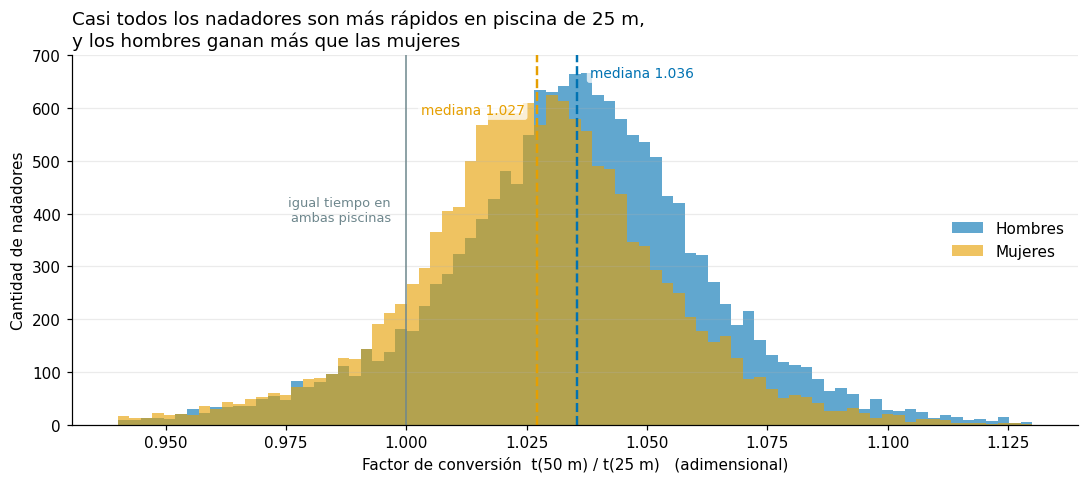

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bordes = np.linspace(0.94, 1.13, 80)
alturas = {"M": .97, "F": .87}          # alturas distintas: si no, las etiquetas se pisan
lados   = {"M": (8, "left"), "F": (-8, "right")}
for sexo, color, nom in [("M", "#0072B2", "Hombres"), ("F", "#E69F00", "Mujeres")]:
    v = pares.loc[pares["sexo"] == sexo, "factor"]
    ax.hist(v, bins=bordes, alpha=.62, color=color, label=nom, edgecolor="none")
    ax.axvline(v.median(), color=color, linestyle="--", linewidth=1.6)
    dx, ha = lados[sexo]
    ax.annotate(f"mediana {v.median():.3f}", (v.median(), alturas[sexo]),
                xycoords=("data", "axes fraction"), xytext=(dx, 0),
                textcoords="offset points", color=color, fontsize=9, ha=ha, va="top",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=.75,
                          edgecolor="none"))

ax.axvline(1.0, color=GRIS, linewidth=1)
ax.annotate("igual tiempo en\nambas piscinas", (1.0, .55), xycoords=("data", "axes fraction"),
            xytext=(-10, 0), textcoords="offset points", color=GRIS, fontsize=8.5, ha="right")
ax.set_xlabel("Factor de conversión  t(50 m) / t(25 m)   (adimensional)")
ax.set_ylabel("Cantidad de nadadores")
ax.set_title("Casi todos los nadadores son más rápidos en piscina de 25 m,\n"
             "y los hombres ganan más que las mujeres", fontsize=12, loc="left")
ax.legend(frameon=False, loc="center right")
ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

La masa está a la derecha de 1,0: la piscina corta es más rápida para casi todo el
mundo. Las dos distribuciones tienen forma parecida y están **desplazadas**: la de
los hombres, a la derecha. La cola izquierda —los que fueron más rápidos en 50 m—
es la del 11,5% que documentamos en la sección 1.5.

## 4.2 Boxplot — la dispersión detrás de cada mediana

*Objetivo: las tablas muestran medianas; hace falta ver cuánta variación hay entre
nadadores de una misma prueba, para no leer la mediana como si fuera una constante
física.*

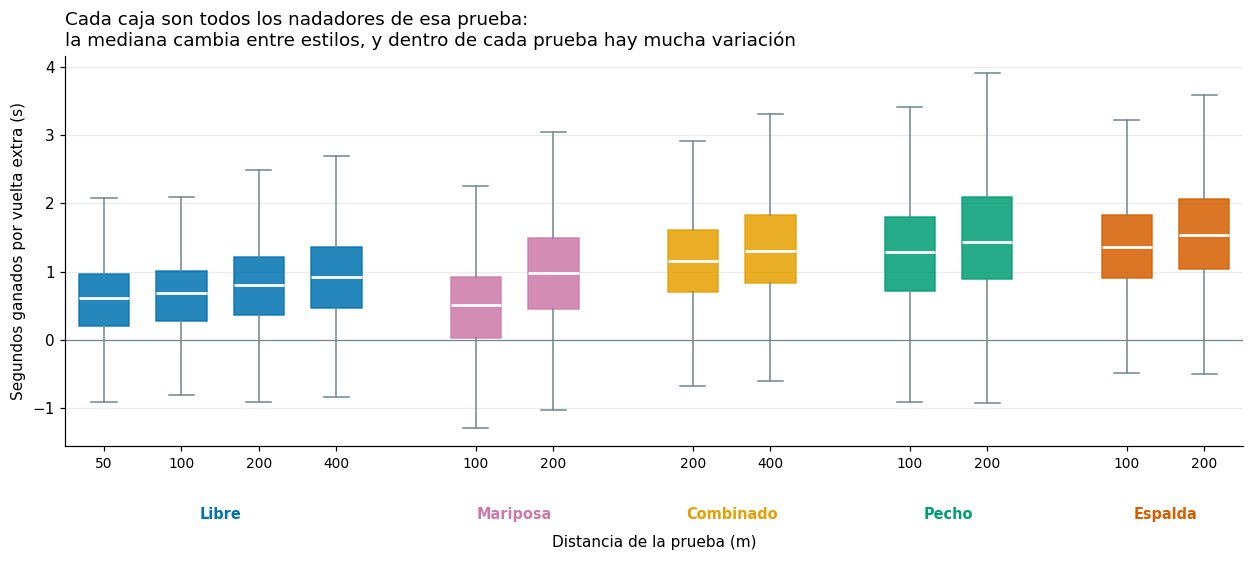

In [24]:
fig, ax = plt.subplots(figsize=(11.5, 5.2))
etiquetas, posiciones, datos, colores = [], [], [], []
grupos = []          # centro de cada estilo, para rotularlo bajo el eje
p = 0
for estilo in ORDEN:
    inicio = p
    for dist in sorted(pares.loc[pares["estilo"] == estilo, "distancia"].unique()):
        v = pares.loc[(pares["estilo"] == estilo) & (pares["distancia"] == dist), "por_vuelta_s"]
        if len(v) < 30:
            continue
        datos.append(v.values); posiciones.append(p); colores.append(COLORES[estilo])
        etiquetas.append(f"{dist}"); p += 1
    grupos.append(((inicio + p - 1) / 2, NOMBRES[estilo], COLORES[estilo]))
    p += 0.8

bp = ax.boxplot(datos, positions=posiciones, widths=.65, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", linewidth=1.8))
for caja, c in zip(bp["boxes"], colores):
    caja.set(facecolor=c, edgecolor=c, alpha=.85)
for parte in ["whiskers", "caps"]:
    for art in bp[parte]:
        art.set(color=GRIS, linewidth=1)

ax.set_xticks(posiciones); ax.set_xticklabels(etiquetas, fontsize=9)
# Etiqueta directa del estilo: el color solo no basta para distinguir
# Mariposa de Pecho en visión con deficiencia de rojo-verde.
for x, nombre, c in grupos:
    ax.annotate(nombre, (x, -0.155), xycoords=("data", "axes fraction"),
                ha="center", va="top", fontsize=9.5, color=c, fontweight="bold")
ax.set_xlabel("Distancia de la prueba (m)", labelpad=42)
ax.set_ylabel("Segundos ganados por vuelta extra (s)")
ax.set_title("Cada caja son todos los nadadores de esa prueba:\n"
             "la mediana cambia entre estilos, y dentro de cada prueba hay mucha variación",
             fontsize=12, loc="left")
ax.axhline(0, color=GRIS, linewidth=.8)
ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Las cajas se desplazan hacia arriba de izquierda a derecha —el orden de estilos de
la sección 3.4— pero **se superponen mucho**: la ventaja por vuelta de un nadador
concreto de libre puede ser mayor que la de uno de espalda. El patrón es de
poblaciones, no de individuos, y así hay que enunciarlo en el informe.

## 4.3 Dispersión con overplotting tratado — las dos marcas del mismo nadador

*Objetivo: mirar el dato crudo del que sale todo. Son 30.257 puntos sobre cuatro
distancias muy distintas: hay saturación y colas largas, así que se usan hexágonos
con conteo en escala logarítmica y ejes también logarítmicos.*

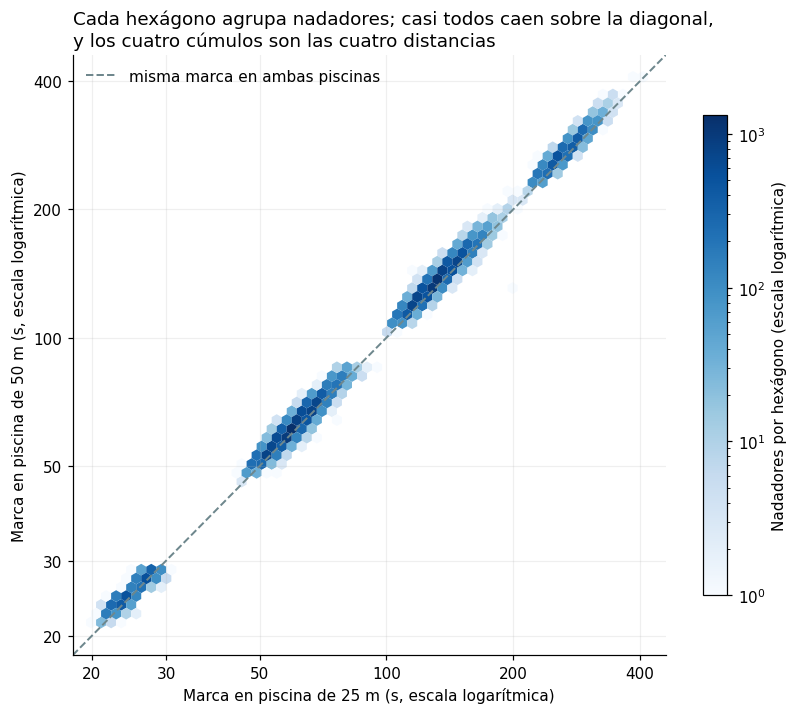

In [25]:
fig, ax = plt.subplots(figsize=(7.6, 6.6))
hb = ax.hexbin(pares["tiempo_s_scm"], pares["tiempo_s_lcm"],
               gridsize=55, bins="log", xscale="log", yscale="log",
               cmap="Blues", mincnt=1, linewidths=0)
lim = [18, 460]
ax.plot(lim, lim, color=GRIS, linestyle="--", linewidth=1.3,
        label="misma marca en ambas piscinas")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Marca en piscina de 25 m (s, escala logarítmica)")
ax.set_ylabel("Marca en piscina de 50 m (s, escala logarítmica)")
ax.set_title("Cada hexágono agrupa nadadores; casi todos caen sobre la diagonal,\n"
             "y los cuatro cúmulos son las cuatro distancias", fontsize=12, loc="left")
from matplotlib.ticker import FixedLocator, FixedFormatter
marcas = [20, 30, 50, 100, 200, 400]
for eje in (ax.xaxis, ax.yaxis):
    eje.set_major_locator(FixedLocator(marcas))
    eje.set_major_formatter(FixedFormatter([str(m) for m in marcas]))
    eje.set_minor_locator(FixedLocator([]))
cb = fig.colorbar(hb, ax=ax, shrink=.8)
cb.set_label("Nadadores por hexágono (escala logarítmica)")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=.2, which="both")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Sin el tratamiento —hexágonos, conteo en log y ejes en log— esto sería una mancha
negra en la esquina inferior izquierda con cuatro puntos sueltos arriba. Así se ve
lo que importa: los cuatro cúmulos son las cuatro distancias, y **la nube está
íntegra por encima de la diagonal**, es decir, la marca de 50 m es más lenta. La
separación respecto de la diagonal es tan pequeña en escala logarítmica que ya
adelanta algo: el efecto es de un 3%, no de un 30%.

## 4.4 Líneas — la prueba de la hipótesis, gráfica

*Objetivo: la hipótesis dice que si cada vuelta valiera lo mismo, estas líneas
serían planas y estarían encima unas de otras. Basta mirarlas.*

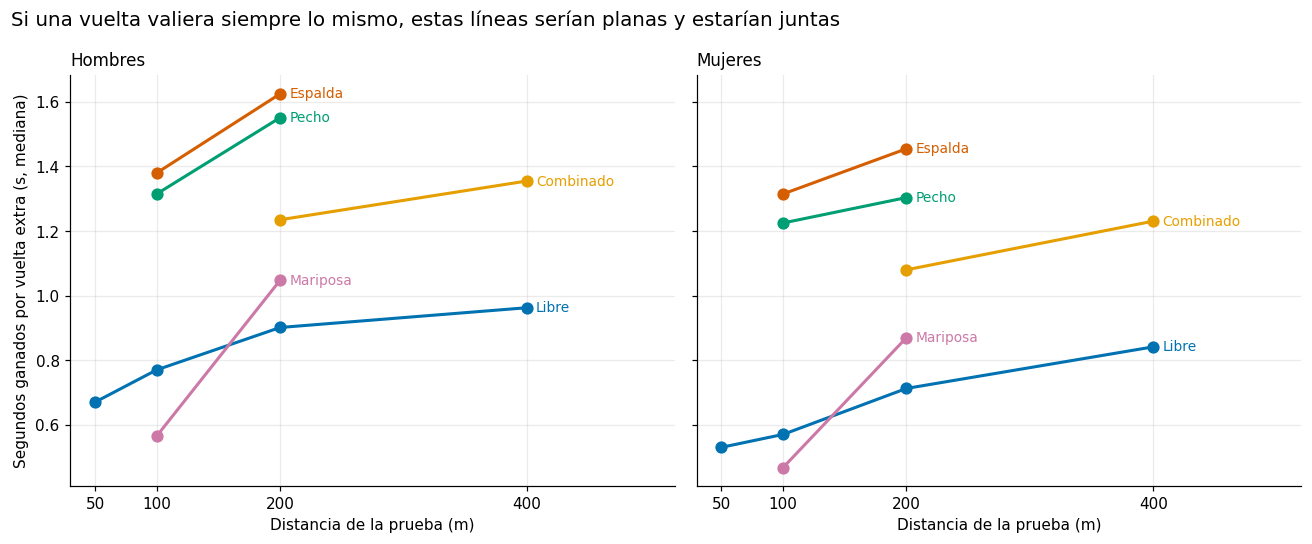

In [26]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, sexo, titulo in zip(ejes, ["M", "F"], ["Hombres", "Mujeres"]):
    d = pares[pares["sexo"] == sexo]
    for estilo in ORDEN:
        s = d[d["estilo"] == estilo].groupby("distancia")["por_vuelta_s"].median()
        if s.empty:
            continue
        ax.plot(s.index, s.values, marker="o", markersize=7, linewidth=2,
                color=COLORES[estilo], label=NOMBRES[estilo])
        ax.annotate(NOMBRES[estilo], (s.index[-1], s.values[-1]),
                    xytext=(6, 0), textcoords="offset points",
                    color=COLORES[estilo], fontsize=9, va="center")
    ax.set_title(titulo, fontsize=11, loc="left")
    ax.set_xlabel("Distancia de la prueba (m)")
    ax.set_xticks([50, 100, 200, 400])
    ax.grid(alpha=.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(30, 520)

ejes[0].set_ylabel("Segundos ganados por vuelta extra (s, mediana)")
fig.suptitle("Si una vuelta valiera siempre lo mismo, estas líneas serían planas y estarían juntas",
             fontsize=13, x=0.01, ha="left")
plt.tight_layout()
plt.show()

Ni planas ni juntas: espalda y pecho van arriba, mariposa abajo, y todas suben con
la distancia. **El mismo orden en los dos paneles.** La hipótesis del modelo simple
queda descartada por partida doble: la ventaja por vuelta depende del estilo y
depende de la distancia.

## 4.5 Barras — lo medido contra lo que exige la federación

*Objetivo: traducir el hallazgo a la decisión que motiva el proyecto. La razón entre
las dos marcas mínimas de World Aquatics es la equivalencia que la federación aplica
de hecho; la comparamos con la medida.*

Las mínimas están transcritas del documento oficial de clasificación al Mundial de
25 m de Beijing 2026 y se calculan en `factor_implicito_wa.py`.

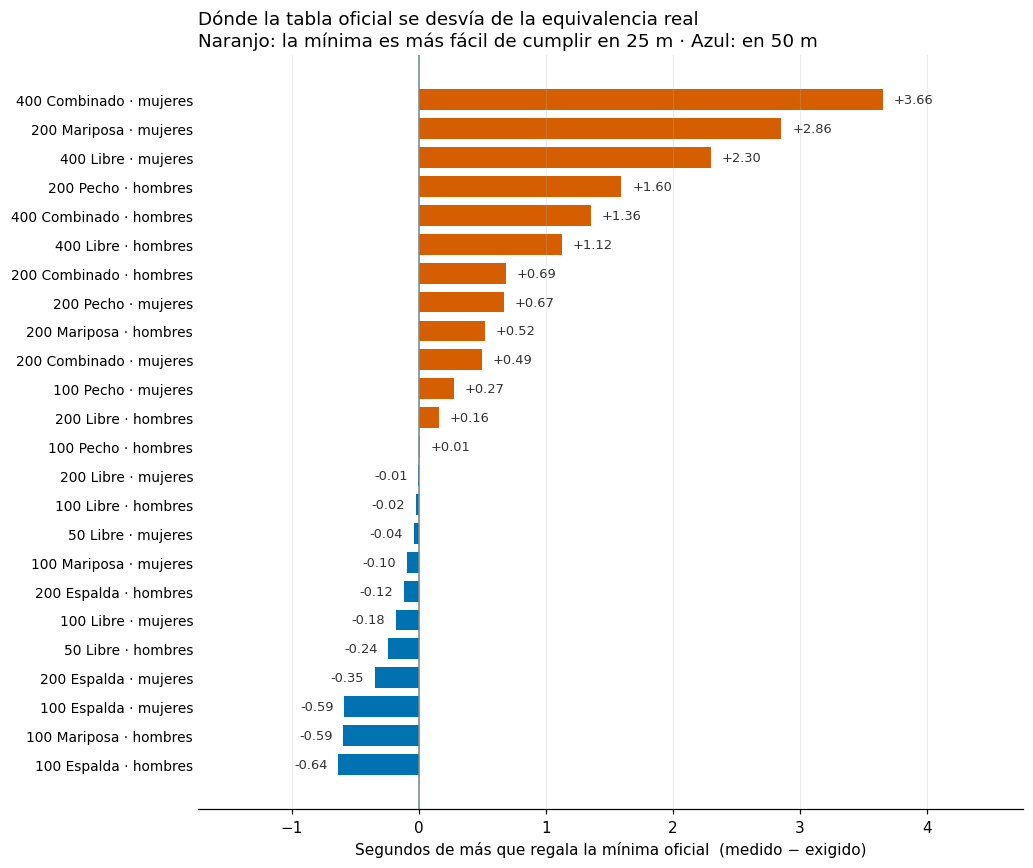

In [27]:
comp = pd.read_csv("datos/comparacion_wa.csv")
comp["etiqueta"] = comp["prueba"] + " · " + comp["sexo"].map({"M": "hombres", "F": "mujeres"})
comp = comp.sort_values("brecha_s")

AZUL, NARANJA = "#0072B2", "#D55E00"
colores_b = np.where(comp["brecha_s"] >= 0, NARANJA, AZUL)

fig, ax = plt.subplots(figsize=(9.5, 8))
ax.barh(comp["etiqueta"], comp["brecha_s"], color=colores_b, height=.72)
ax.axvline(0, color=GRIS, linewidth=1)
for y, (v, et) in enumerate(zip(comp["brecha_s"], comp["etiqueta"])):
    ax.annotate(f"{v:+.2f}", (v, y), xytext=(7 if v >= 0 else -7, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5, color="#333333")
ax.set_xlabel("Segundos de más que regala la mínima oficial  (medido − exigido)")
ax.set_title("Dónde la tabla oficial se desvía de la equivalencia real\n"
             "Naranjo: la mínima es más fácil de cumplir en 25 m · Azul: en 50 m",
             fontsize=12, loc="left")
ax.set_xlim(comp["brecha_s"].min() - 1.1, comp["brecha_s"].max() + 1.1)
ax.grid(axis="x", alpha=.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=9)
plt.tight_layout()
plt.show()

In [28]:
print(f"Pruebas más fáciles de clasificar en 25 m: {(comp['brecha_s'] > 0).sum()}")
print(f"Pruebas más fáciles de clasificar en 50 m: {(comp['brecha_s'] < 0).sum()}")
print(f"Brecha absoluta mediana: {comp['brecha_s'].abs().median():.2f} s")
print(f"Pruebas con brecha menor a 0,3 s: {(comp['brecha_s'].abs() < 0.3).sum()} de {len(comp)}")
r_wa = comp[["factor_wa_A", "factor_real"]].corr().iloc[0, 1]
print(f"\nCorrelación entre el factor oficial y el medido: {r_wa:.3f}")

Pruebas más fáciles de clasificar en 25 m: 13
Pruebas más fáciles de clasificar en 50 m: 11
Brecha absoluta mediana: 0.51 s
Pruebas con brecha menor a 0,3 s: 10 de 24

Correlación entre el factor oficial y el medido: 0.767


**Interpretación, con cuidado.** La correlación de 0,77 entre ambos factores dice
que la tabla oficial **no es arbitraria**: captura la tendencia por estilo. En 10 de
las 24 pruebas la brecha es menor a 0,3 s, que es ruido para efectos prácticos. Y
las desviaciones no apuntan todas al mismo lado: 13 pruebas son más fáciles en 25 m
y 11 en 50 m.

Lo que los datos muestran, entonces, no es "la tabla está mal calibrada" sino que
**se desvía de forma inconsistente en un subconjunto de pruebas**, con casos como
los 400 combinado o los 200 mariposa femeninos donde la diferencia supera los
2,8 s. Esa es una afirmación que los datos sostienen; la otra, no.

---
# 5. Hallazgos y siguientes pasos

In [29]:
extremos = (pares.groupby(["sexo", "estilo", "distancia"])["factor"].median()
                 .sort_values())
print("Las tres pruebas con menor factor:")
for (s, e, d), v in extremos.head(3).items():
    print(f"   {d:3d} {NOMBRES[e]:10} {'hombres' if s=='M' else 'mujeres':8} {v:.4f}")
print("\nLas tres pruebas con mayor factor:")
for (s, e, d), v in extremos.tail(3).items():
    print(f"   {d:3d} {NOMBRES[e]:10} {'hombres' if s=='M' else 'mujeres':8} {v:.4f}")
print(f"\nRango completo: {extremos.min():.4f} a {extremos.max():.4f}")
print(f"La ventaja de nadar en piscina corta va de {(extremos.min()-1)*100:.1f}% a "
      f"{(extremos.max()-1)*100:.1f}% del tiempo total, según la prueba: "
      f"{(extremos.max()-1)/(extremos.min()-1):.1f} veces más en una que en otra.")

Las tres pruebas con menor factor:
   100 Mariposa   mujeres  1.0145
   100 Libre      mujeres  1.0198
    50 Libre      mujeres  1.0201

Las tres pruebas con mayor factor:
   200 Pecho      hombres  1.0450
   100 Espalda    hombres  1.0491
   200 Espalda    hombres  1.0521

Rango completo: 1.0145 a 1.0521
La ventaja de nadar en piscina corta va de 1.5% a 5.2% del tiempo total, según la prueba: 3.6 veces más en una que en otra.


## Los cinco hallazgos

1. **El factor de conversión entre piscina de 25 y 50 m no es una constante: va de
   1,015 a 1,052 según la prueba**, es decir, la ventaja de nadar en piscina corta
   varía en un factor de más de tres entre la prueba donde menos importa (100 m
   mariposa femenino) y aquella donde más (200 m espalda masculino). Cualquier
   calculadora que use un único número está equivocada en la mayoría de las pruebas.

2. **La hipótesis del modelo simple —cada vuelta extra vale lo mismo— queda
   descartada.** Si fuera cierta, los segundos ganados por vuelta serían iguales
   entre estilos y distancias; medidos sobre 30.257 pares, crecen con la distancia
   en los diez casos donde hay más de una distancia, y siguen el mismo orden de
   estilos en hombres y mujeres (mariposa < libre < combinado < pecho < espalda).
   Que el orden se repita en dos poblaciones independientes indica que responde a la
   mecánica del nado y no al ruido de la muestra.

3. **Los hombres se benefician más de la piscina corta que las mujeres en las doce
   pruebas comparadas, sin excepción**, con diferencias de 0,6 a 1,2 puntos
   porcentuales, significativas en todas (Mann-Whitney, p < 1e-7). Este resultado
   contradice a Iglesias García et al. (2025), que reporta diferencias mínimas por
   sexo sobre los rankings españoles, y coincide con el análisis de récords de Curl
   (2014).

4. **La equivalencia implícita en las marcas mínimas de World Aquatics captura la
   tendencia por estilo (correlación 0,77 con el factor medido), pero se desvía de
   forma inconsistente en un subconjunto de pruebas.** En 10 de 24 pruebas la brecha
   es menor a 0,3 s, pero en los 400 m combinado y los 200 m mariposa femeninos
   supera los 2,8 s; y 13 pruebas resultan más fáciles de clasificar en 25 m contra
   11 en 50 m. La consecuencia práctica para un nadador es que **la piscina en la
   que conviene intentar la mínima depende de su prueba**.

5. **El aparente efecto del nivel del nadador sobre el factor es un artefacto de
   selección, no un fenómeno.** Al ser el factor un cociente, definir "élite" por el
   tiempo de uno de los dos lados mueve la mediana casi un punto porcentual sin que
   cambie ningún nadador; con una definición neutral el efecto cae hasta volverse
   irrelevante (rho de Spearman −0,08 contra −0,28 del criterio sesgado:
   significativo por el tamaño de la muestra, sin importancia práctica). El
   hallazgo importa porque valida comparar nuestra mediana poblacional con una tabla
   de marcas mínimas de nivel más alto.

## El modelo que viene

El análisis exploratorio deja planteada una regresión que se ajustará en el informe
de avance:

$$\text{diferencia\_s} = \beta_0 + \beta_1 \cdot \text{vueltas\_extra} + \varepsilon$$

estimada **por estilo y sexo** (equivalentemente, un modelo múltiple con la
interacción `vueltas_extra × estilo`, que es lo trabajado en la clase 4 con variables
dummy). La lectura es directa:

- **La pendiente $\beta_1$ es la ventaja por vuelta** de ese estilo, con su intervalo
  de confianza. Comparar pendientes entre estilos es la forma formal de la pregunta.
- **El intercepto $\beta_0$ dice si hay algo más en juego además de las vueltas.**
  Si el modelo simple fuera correcto, debería ser cero: sin vueltas extra, no hay
  diferencia. Un intercepto significativamente distinto de cero apuntaría a un
  segundo mecanismo (la salida, o el desgaste distinto entre calendarios).

Con las herramientas de la clase 5 se agregarán además **intervalos de confianza
para el factor de cada prueba** —hoy sólo tenemos la mediana puntual— y una prueba
de hipótesis formal para la brecha entre sexos. Con las de la clase 7, una regresión
regularizada para comprobar que las conclusiones no dependen de las pruebas con
menos pares.

## Limitaciones declaradas

1. La muestra son los 5.000 mejores de cada prueba, no una muestra aleatoria:
   describe a la élite competitiva, no a la población de nadadores.
2. Un nadador puede estar en distinta forma en la temporada de piscina corta y en la
   de larga; el diseño dentro-nadador no elimina eso, sólo lo promedia sobre miles
   de casos. Es el origen del 11,5% de pares con la piscina de 50 m más rápida.
3. Un solo año (2024). Ampliable editando `ANIOS` en `descargar.py`.
4. Los términos legales de World Aquatics prohíben la extracción automatizada y la
   redistribución de sus contenidos. El uso aquí es académico, con pausa entre
   peticiones y caché local, y **no se redistribuyen los datos crudos**.